In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
print(os.listdir('/content/drive/MyDrive/flood_detection/data'))

['metadata.csv', 'Image', 'Mask']


# **1. Installing & Importing Libraries**

In [6]:
# Install any missing libraries
!pip install albumentations -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     UpSampling2D, concatenate,
                                     BatchNormalization, Dropout, Activation)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **2. Configuration**

In [7]:
IMAGE_PATH = "/content/drive/MyDrive/flood_detection/data/Image/"
MASK_PATH  = "/content/drive/MyDrive/flood_detection/data/Mask/"
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 30
SEED       = 42

print("Images available:", len(os.listdir(IMAGE_PATH)))
print("Masks available :", len(os.listdir(MASK_PATH)))

Images available: 290
Masks available : 290


# **3. Loading & Preprocessing Data**

In [8]:
def load_data(image_dir, mask_dir, img_size):
    images, masks = [], []
    filenames = sorted(os.listdir(image_dir))

    print(f"Loading {len(filenames)} images...")
    for fname in tqdm(filenames):
        # Load image
        img_path = os.path.join(image_dir, fname)
        img      = cv2.imread(img_path)
        img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img      = cv2.resize(img, (img_size, img_size))
        img      = img / 255.0

        # Load mask
        mask_name = fname.replace(".jpg", ".png")
        mask_path = os.path.join(mask_dir, mask_name)
        mask      = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask      = cv2.resize(mask, (img_size, img_size))
        mask      = (mask > 127).astype(np.float32)
        mask      = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

X, y = load_data(IMAGE_PATH, MASK_PATH, IMG_SIZE)
print(f"\nImages shape : {X.shape}")
print(f"Masks shape  : {y.shape}")
print(f"Flood pixels : {y.mean()*100:.2f}%")

Loading 290 images...


100%|██████████| 290/290 [05:03<00:00,  1.05s/it]


Images shape : (290, 256, 256, 3)
Masks shape  : (290, 256, 256, 1)
Flood pixels : 40.70%


# **4. Visualizing Sample Data**

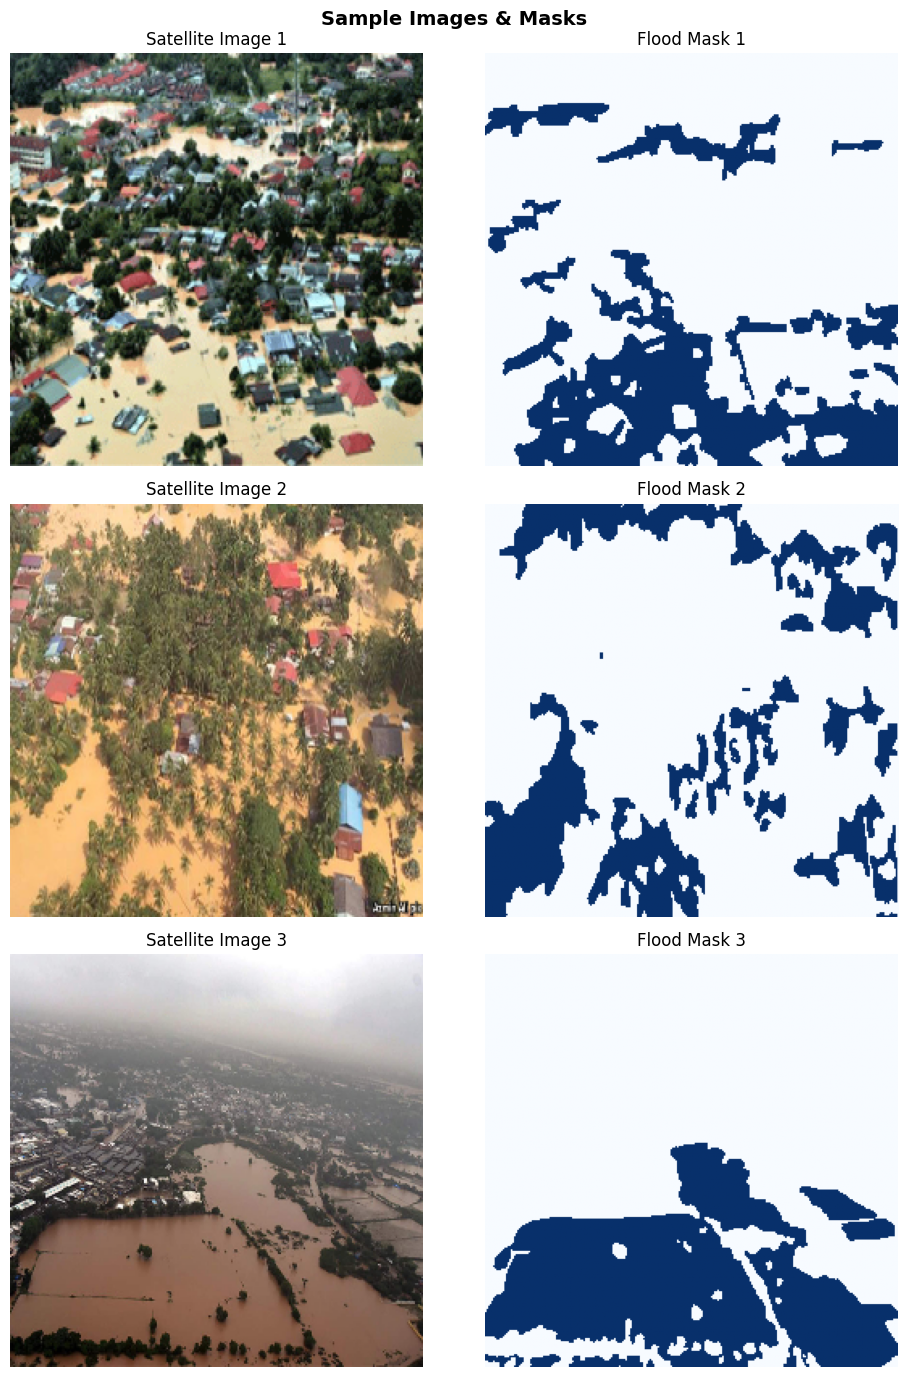

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

for i in range(3):
    axes[i, 0].imshow(X[i])
    axes[i, 0].set_title(f"Satellite Image {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y[i].squeeze(), cmap="Blues")
    axes[i, 1].set_title(f"Flood Mask {i+1}")
    axes[i, 1].axis("off")

plt.suptitle("Sample Images & Masks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# **5. Splitting Data**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED)

print(f"Train : {len(X_train)} images")
print(f"Val   : {len(X_val)} images")
print(f"Test  : {len(X_test)} images")

Train : 208 images
Val   : 24 images
Test  : 58 images


# **6. Data Augmentation Generator**

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def augment_data(X, y, augment_factor=3):
    """Triple the dataset using augmentation"""
    augmented_images = []
    augmented_masks  = []

    for i in range(len(X)):
        img  = X[i]
        mask = y[i]

        # Original
        augmented_images.append(img)
        augmented_masks.append(mask)

        for _ in range(augment_factor - 1):
            # Random horizontal flip
            if np.random.random() > 0.5:
                img  = np.fliplr(img)
                mask = np.fliplr(mask)

            # Random vertical flip
            if np.random.random() > 0.5:
                img  = np.flipud(img)
                mask = np.flipud(mask)

            # Random 90 degree rotation
            k = np.random.choice([0, 1, 2, 3])
            img  = np.rot90(img, k)
            mask = np.rot90(mask, k)

            # Random brightness adjustment
            brightness = np.random.uniform(0.8, 1.2)
            img = np.clip(img * brightness, 0, 1)

            augmented_images.append(img.copy())
            augmented_masks.append(mask.copy())

    X_aug = np.array(augmented_images, dtype=np.float32)
    y_aug = np.array(augmented_masks,  dtype=np.float32)

    # Shuffle
    idx   = np.random.permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]

print("Augmenting training data...")
X_train_aug, y_train_aug = augment_data(X_train, y_train, augment_factor=4)
print(f"Original train size  : {len(X_train)}")
print(f"Augmented train size : {len(X_train_aug)}")

Augmenting training data...
Original train size  : 208
Augmented train size : 832


## **7. Custom Loss & Metrics**

In [16]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print("Metrics defined!")

Metrics defined!


# **8. Building U-Net Model**

In [17]:
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 16);  p1 = MaxPooling2D(2)(c1);  p1 = Dropout(0.2)(p1)
    c2 = conv_block(p1, 32);      p2 = MaxPooling2D(2)(c2);  p2 = Dropout(0.2)(p2)
    c3 = conv_block(p2, 64);      p3 = MaxPooling2D(2)(c3);  p3 = Dropout(0.3)(p3)
    c4 = conv_block(p3, 128);     p4 = MaxPooling2D(2)(c4);  p4 = Dropout(0.3)(p4)

    # Bottleneck
    c5 = conv_block(p4, 256)

    # Decoder
    u6 = UpSampling2D(2)(c5);  u6 = concatenate([u6, c4]);  c6 = conv_block(u6, 128);  c6 = Dropout(0.3)(c6)
    u7 = UpSampling2D(2)(c6);  u7 = concatenate([u7, c3]);  c7 = conv_block(u7, 64);   c7 = Dropout(0.3)(c7)
    u8 = UpSampling2D(2)(c7);  u8 = concatenate([u8, c2]);  c8 = conv_block(u8, 32);   c8 = Dropout(0.2)(c8)
    u9 = UpSampling2D(2)(c8);  u9 = concatenate([u9, c1]);  c9 = conv_block(u9, 16);   c9 = Dropout(0.2)(c9)

    outputs = Conv2D(1, 1, activation="sigmoid")(c9)

    model = Model(inputs, outputs, name="U-Net")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=combined_loss,
        metrics=[dice_coefficient, iou_score]
    )
    return model

model = build_unet()
print("U-Net model built successfully!")

U-Net model built successfully!


# **9. Training the Model with augmented data**

In [18]:
callbacks = [
    EarlyStopping(monitor="val_dice_coefficient", patience=7,
                  restore_best_weights=True, mode="max", verbose=1),
    ModelCheckpoint("/content/drive/MyDrive/flood_detection/best_model.keras",
                    monitor="val_dice_coefficient", mode="max",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, verbose=1)
]

history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - dice_coefficient: 0.6552 - iou_score: 0.5715 - loss: 0.8602
Epoch 1: val_dice_coefficient improved from None to 0.56042, saving model to /content/drive/MyDrive/flood_detection/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/flood_detection/best_model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - dice_coefficient: 0.6859 - iou_score: 0.6071 - loss: 0.7768 - val_dice_coefficient: 0.5604 - val_iou_score: 0.3918 - val_loss: 3.9969 - learning_rate: 0.0010
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - dice_coefficient: 0.7082 - iou_score: 0.6359 - loss: 0.7164
Epoch 2: val_dice_coefficient improved from 0.56042 to 0.56172, saving model to /content/drive/MyDrive/flood_detection/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/flood_detection/best_model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - dice_coefficient: 0.7152 - iou_score: 0.6409 - loss: 0.7053 - val_dice_

# **10. Evaluating on Test Set**

In [19]:
print("Evaluating on test set...")
results = model.evaluate(X_test, y_test, verbose=1)
print(f"\n  Test Loss       : {results[0]:.4f}")
print(f"  Test Dice Score : {results[1]:.4f}")
print(f"  Test IoU Score  : {results[2]:.4f}")

Evaluating on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 7s/step - dice_coefficient: 0.8353 - iou_score: 0.7621 - loss: 0.4567

  Test Loss       : 0.4567
  Test Dice Score : 0.8353
  Test IoU Score  : 0.7621


## **11. Plot Training History**

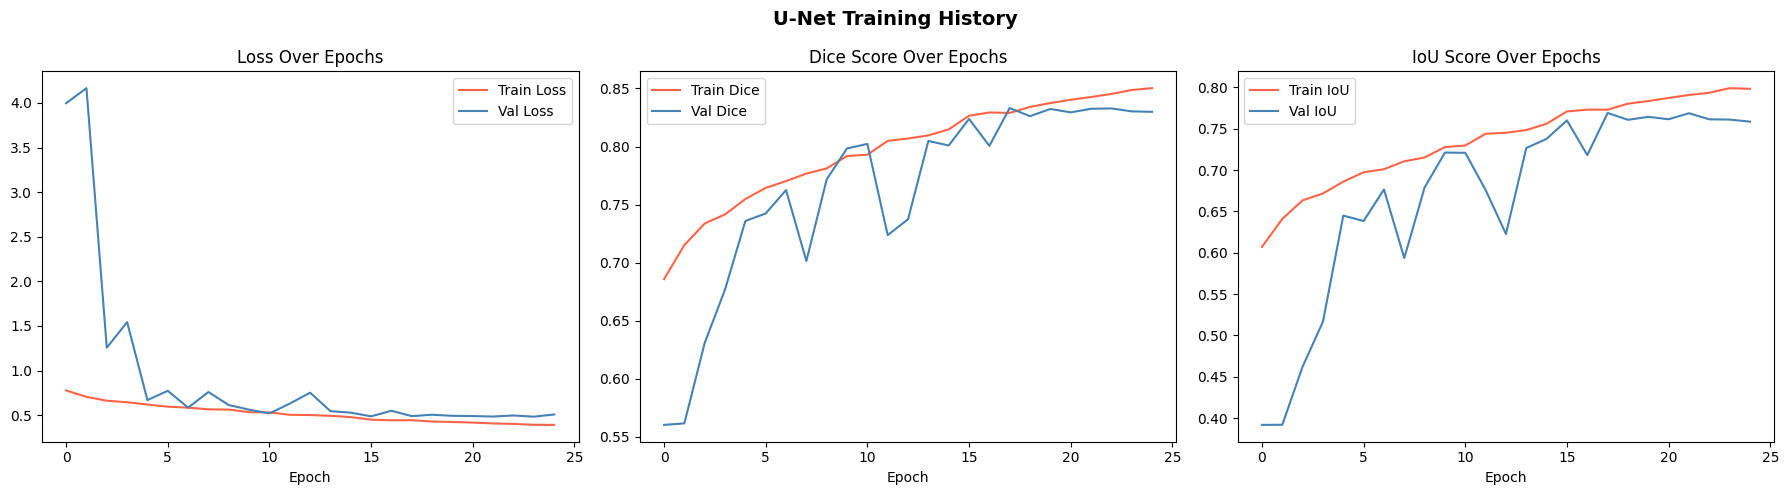

Saved: training_history.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history["loss"],     label="Train Loss", color="tomato")
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="steelblue")
axes[0].set_title("Loss Over Epochs"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history.history["dice_coefficient"],     label="Train Dice", color="tomato")
axes[1].plot(history.history["val_dice_coefficient"], label="Val Dice",   color="steelblue")
axes[1].set_title("Dice Score Over Epochs"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history.history["iou_score"],     label="Train IoU", color="tomato")
axes[2].plot(history.history["val_iou_score"], label="Val IoU",   color="steelblue")
axes[2].set_title("IoU Score Over Epochs"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.suptitle("U-Net Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/flood_detection/training_history.png", dpi=150)
plt.show()
print("Saved: training_history.png")

# **12. Visual Predictions**

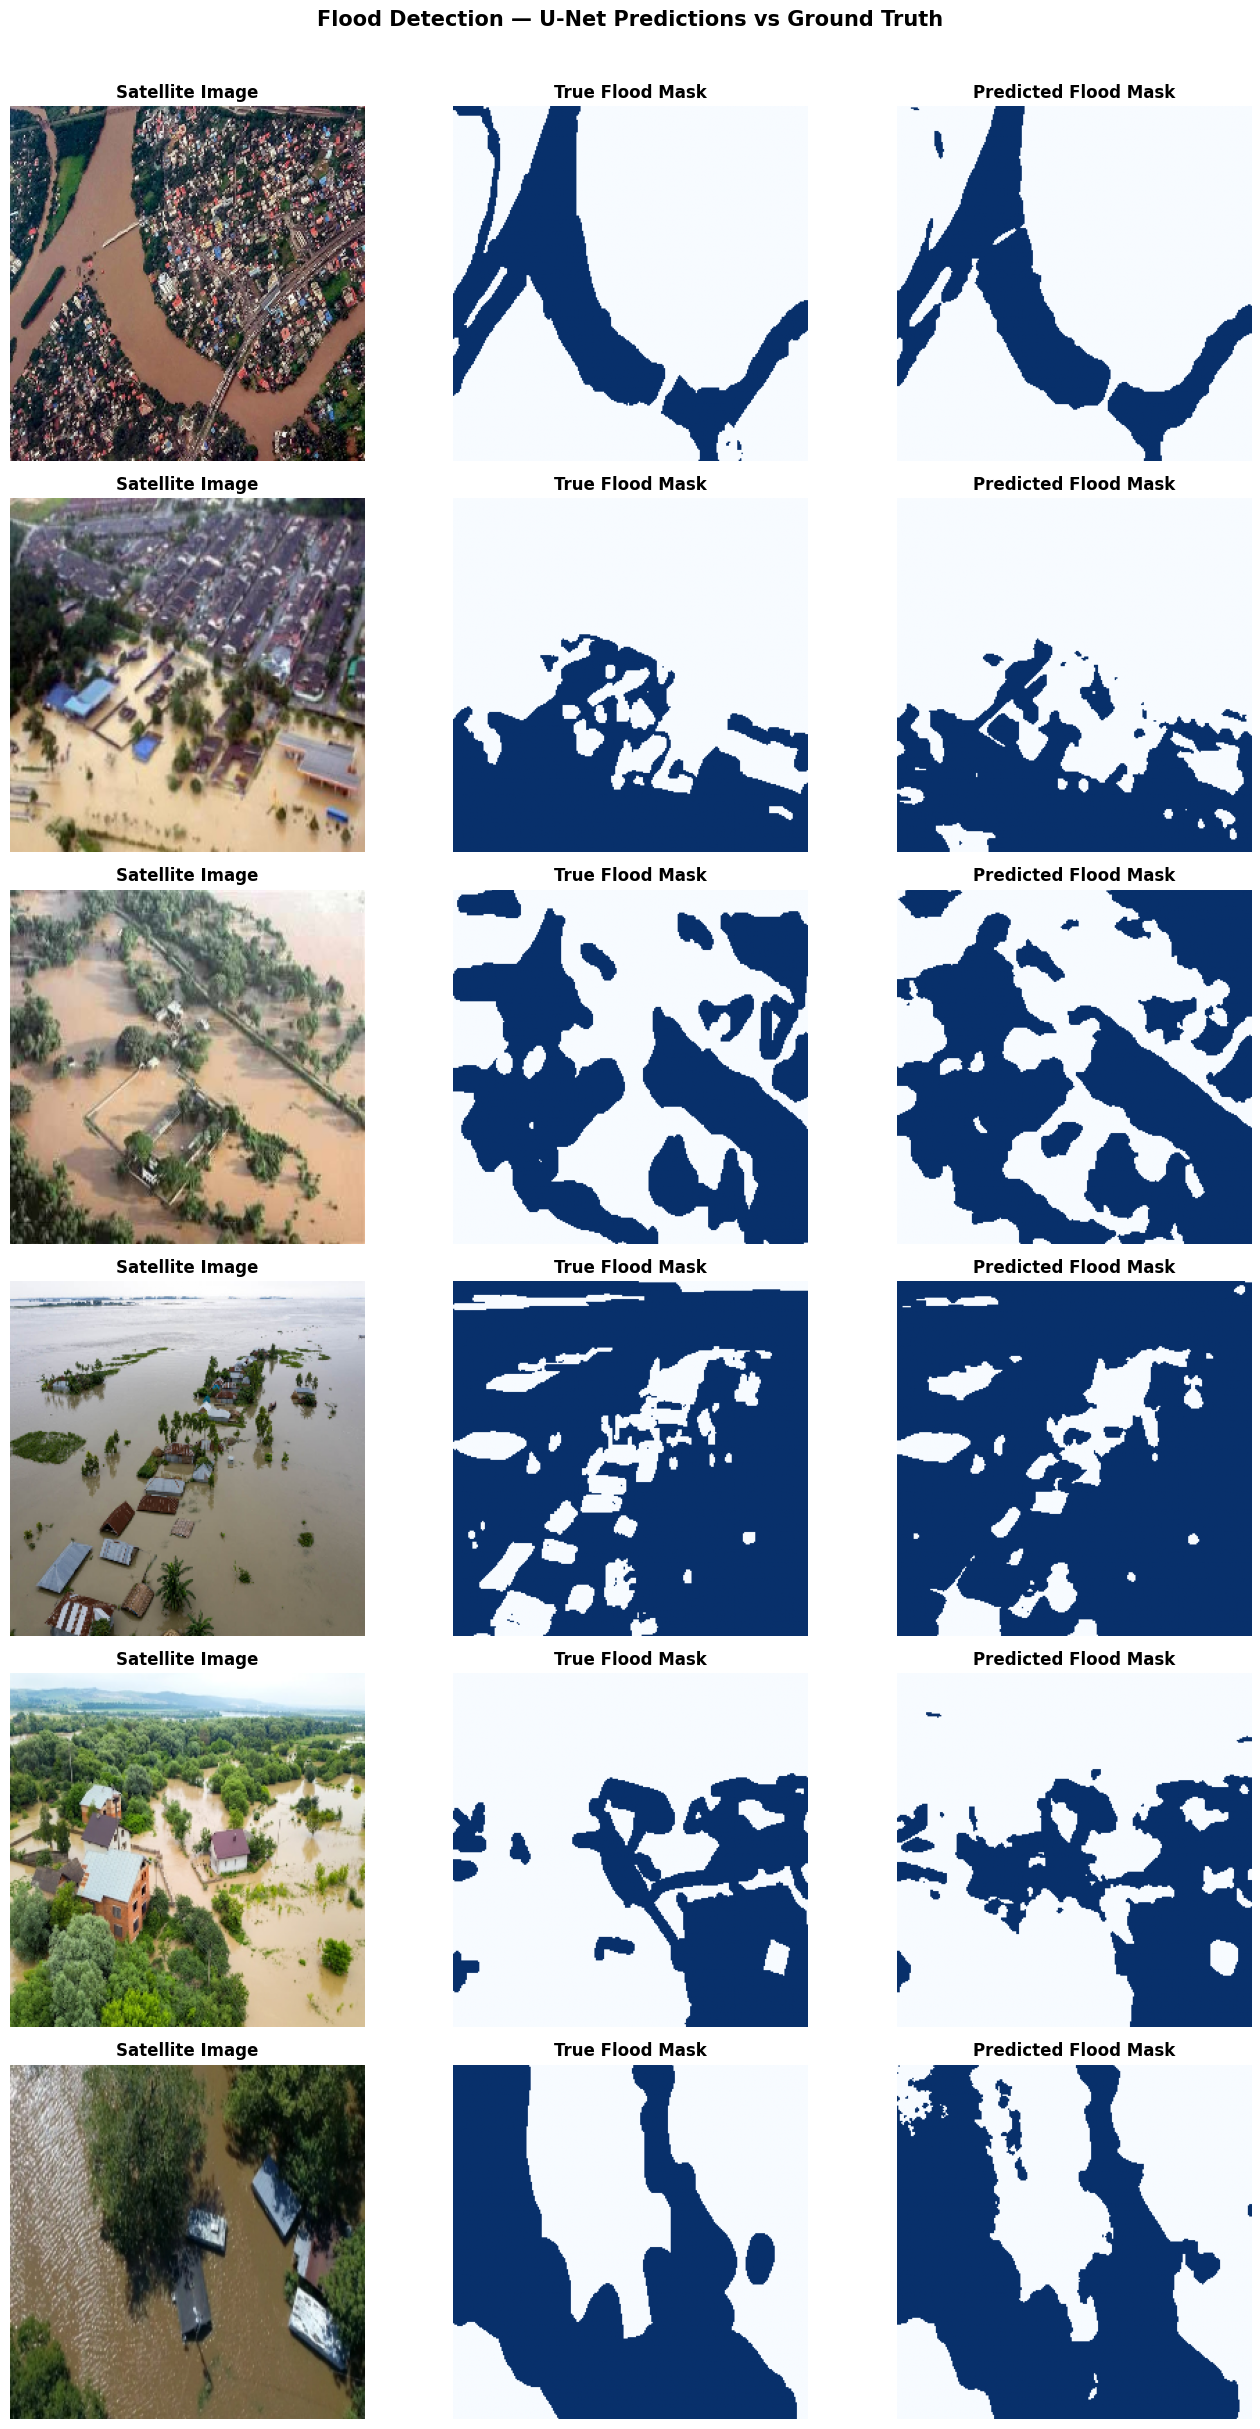

Saved: predictions.png


In [23]:
def visualize_predictions(model, X, y, n=6):
    preds = model.predict(X[:n], verbose=0)

    fig, axes = plt.subplots(n, 3, figsize=(14, n * 4))
    titles = ["Satellite Image", "True Flood Mask", "Predicted Flood Mask"]

    for i in range(n):
        # Original satellite image
        axes[i, 0].imshow(X[i])
        axes[i, 0].set_title(titles[0], fontweight="bold")
        axes[i, 0].axis("off")

        # Ground truth mask
        axes[i, 1].imshow(y[i].squeeze(), cmap="Blues")
        axes[i, 1].set_title(titles[1], fontweight="bold")
        axes[i, 1].axis("off")

        # Predicted mask
        pred_mask = (preds[i].squeeze() > 0.5).astype(np.float32)
        axes[i, 2].imshow(pred_mask, cmap="Blues")
        axes[i, 2].set_title(titles[2], fontweight="bold")
        axes[i, 2].axis("off")

    plt.suptitle("Flood Detection — U-Net Predictions vs Ground Truth",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/flood_detection/predictions.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: predictions.png")

visualize_predictions(model, X_test, y_test, n=6)

# **13. Overlay Visualization (flood map on top of satellite image)**

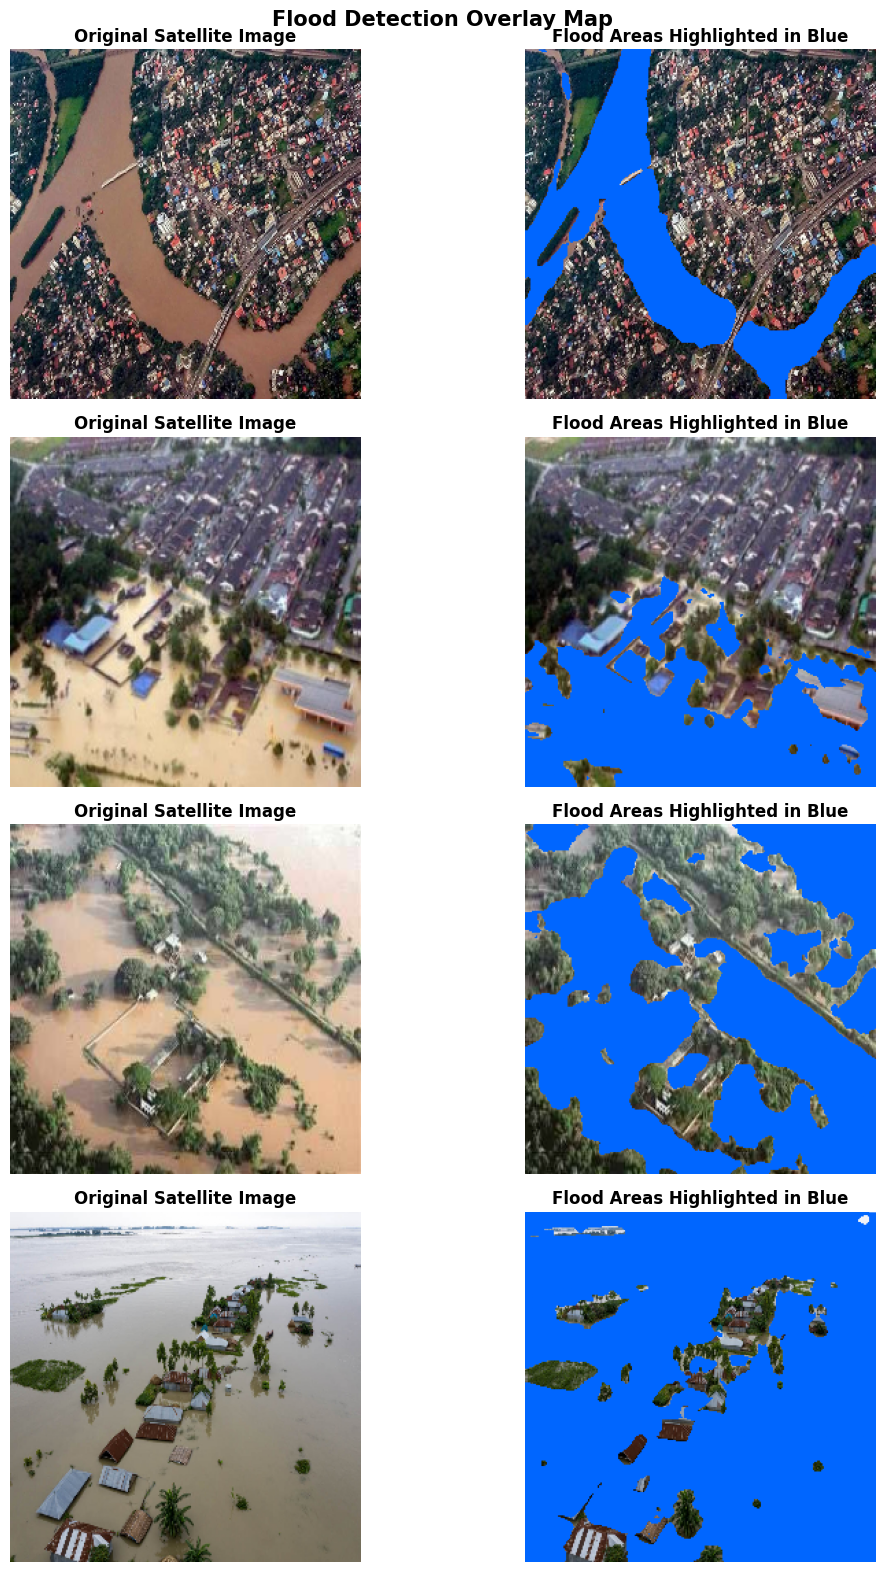

Saved: overlay_map.png


In [22]:
def overlay_predictions(model, X, y, n=4):
    preds = model.predict(X[:n], verbose=0)

    fig, axes = plt.subplots(n, 2, figsize=(12, n * 4))

    for i in range(n):
        img       = X[i].copy()
        pred_mask = (preds[i].squeeze() > 0.5)

        # Create overlay — flood areas highlighted in blue
        overlay        = img.copy()
        overlay[pred_mask, 0] = 0.0   # R
        overlay[pred_mask, 1] = 0.4   # G
        overlay[pred_mask, 2] = 1.0   # B (blue highlight)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Original Satellite Image", fontweight="bold")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title("Flood Areas Highlighted in Blue", fontweight="bold")
        axes[i, 1].axis("off")

    plt.suptitle("Flood Detection Overlay Map", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/flood_detection/overlay_map.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: overlay_map.png")

overlay_predictions(model, X_test, y_test, n=4)